In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("--> 库导入完成")

--> 库导入完成


In [2]:
# 读取原始数据（假设原始单位为英寸和磅）
df = pd.read_csv("women.csv")
# 单位换算
df["height_cm"] = df["height"] * 2.54  # 英寸转厘米
df["weight_kg"] = df["weight"] / 2.2046  # 磅转公斤

print("--> 数据加载完成，单位已转换：")
print(df[["height_cm", "weight_kg"]].head(3))

--> 数据加载完成，单位已转换：
   height_cm  weight_kg
0     147.32  52.163658
1     149.86  53.070852
2     152.40  54.431643


In [3]:
# 提取特征和标签
X = df["height_cm"].values
y = df["weight_kg"].values

# 特征标准化
X_mean, X_std = X.mean(), X.std()
X_normalized = (X - X_mean) / X_std

print(f"--> 标准化参数：均值={X_mean:.2f}cm，标准差={X_std:.2f}cm")
print("标准化后样本示例：", X_normalized[:3])

--> 标准化参数：均值=165.10cm，标准差=10.97cm
标准化后样本示例： [-1.62018517 -1.38873015 -1.15727512]


In [4]:
# 超参数设置
learning_rate = 0.1
n_iterations = 100

# 参数初始化
theta = np.random.randn(2)  # [截距, 斜率]
m = len(X)

# 添加偏置项
X_b = np.c_[np.ones((m, 1)), X_normalized]

# 存储损失历史
loss_history = []

# 梯度下降迭代
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta -= learning_rate * gradients
    loss = np.mean((X_b.dot(theta) - y)**2)
    loss_history.append(loss)

print("--> 梯度下降完成")
print(f"最终参数：截距={theta[0]:.2f}，斜率={theta[1]:.2f}")

--> 梯度下降完成
最终参数：截距=62.02，斜率=6.76


In [5]:
# 将斜率反标准化到原始尺度
theta_original = np.array([
    theta[0] - theta[1]*X_mean/X_std,  # 调整截距
    theta[1]/X_std  # 调整斜率
])

print("--> 反标准化后参数：")
print(f"回归方程：weight_kg = {theta_original[1]:.2f}*height_cm + {theta_original[0]:.2f}")

--> 反标准化后参数：
回归方程：weight_kg = 0.62*height_cm + -39.70


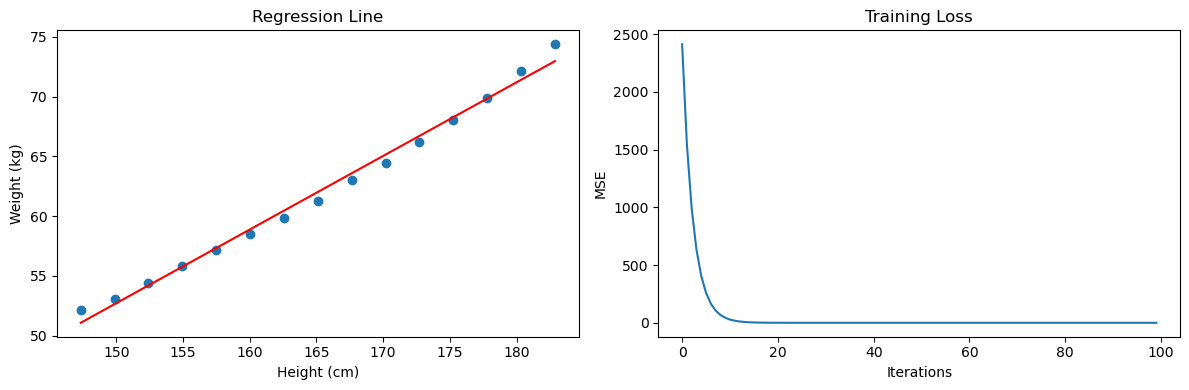

In [6]:
plt.figure(figsize=(12, 4))

# 子图1：原始数据与回归线
plt.subplot(121)
plt.scatter(df["height_cm"], df["weight_kg"])
plt.plot(df["height_cm"], theta_original[1]*df["height_cm"] + theta_original[0], "r")
plt.xlabel("Height (cm)"), plt.ylabel("Weight (kg)")
plt.title("Regression Line")

# 子图2：损失函数下降曲线
plt.subplot(122)
plt.plot(loss_history)
plt.xlabel("Iterations"), plt.ylabel("MSE")
plt.title("Training Loss")

plt.tight_layout()
plt.show()